In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
kideny = pd.read_csv("/content/kidney_disease.csv")

# Inspect data
kideny.head(5)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
kideny=kideny.drop("id", axis=1)
kideny.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [ ]:
# Print summary statistics
kideny_description_numeric = kideny.describe()
# Only considering non-numerical data
kideny_description_obj = kideny.describe(exclude ="number")
print(kideny_description_numeric)

print('\n')

print(kideny_description_obj)

              age  blood_pressure  specific_gravity     albumin       sugar  \
count  391.000000      388.000000        353.000000  354.000000  351.000000   
mean    51.483376       76.469072          1.017408    1.016949    0.450142   
std     17.169714       13.683637          0.005717    1.352679    1.099191   
min      2.000000       50.000000          1.005000    0.000000    0.000000   
25%     42.000000       70.000000          1.010000    0.000000    0.000000   
50%     55.000000       80.000000          1.020000    0.000000    0.000000   
75%     64.500000       80.000000          1.020000    2.000000    0.000000   
max     90.000000      180.000000          1.025000    5.000000    5.000000   

       blood_glucose_random  blood_urea  serum_creatinine      sodium  \
count            356.000000  381.000000        383.000000  313.000000   
mean             148.036517   57.425722          3.072454  137.528754   
std               79.281714   50.503006          5.741126   10.408752

In [ ]:
# Print DataFrame information
kideny_info = kideny.info()
print(kideny_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [ ]:
kideny.isna().sum()

age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
haemoglobin                 52
packed_cell_volume          70
white_blood_cell_count     105
red_blood_cell_count       130
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

In [ ]:
mask = kideny.isna().sum() / len(kideny) < 0.5

# Create a reduced dataset by applying the mask
kideny = kideny.loc[:,mask]

print(kideny.shape)

(400, 25)


In [ ]:
kideny=kideny.fillna(0)
kideny.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    float64
 1   blood_pressure           400 non-null    float64
 2   specific_gravity         400 non-null    float64
 3   albumin                  400 non-null    float64
 4   sugar                    400 non-null    float64
 5   red_blood_cells          400 non-null    object 
 6   pus_cell                 400 non-null    object 
 7   pus_cell_clumps          400 non-null    object 
 8   bacteria                 400 non-null    object 
 9   blood_glucose_random     400 non-null    float64
 10  blood_urea               400 non-null    float64
 11  serum_creatinine         400 non-null    float64
 12  sodium                   400 non-null    float64
 13  potassium                400 non-null    float64
 14  haemoglobin              4

In [ ]:
print(kideny["class"].unique())
print(kideny["coronary_artery_disease"].unique() )

['ckd' 'ckd\t' 'notckd']
['no' 'yes' '\tno' 0]


In [ ]:
kideny=kideny.replace(['ckd', 'ckd\t', 'notckd'],[1,2,0])
kideny["coronary_artery_disease"].mask(kideny["coronary_artery_disease"]==0,"no",inplace=True)

In [ ]:
print(kideny["coronary_artery_disease"].unique() )

['no' 'yes' '\tno']


In [ ]:
kideny.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    float64
 1   blood_pressure           400 non-null    float64
 2   specific_gravity         400 non-null    float64
 3   albumin                  400 non-null    float64
 4   sugar                    400 non-null    float64
 5   red_blood_cells          400 non-null    object 
 6   pus_cell                 400 non-null    object 
 7   pus_cell_clumps          400 non-null    object 
 8   bacteria                 400 non-null    object 
 9   blood_glucose_random     400 non-null    float64
 10  blood_urea               400 non-null    float64
 11  serum_creatinine         400 non-null    float64
 12  sodium                   400 non-null    float64
 13  potassium                400 non-null    float64
 14  haemoglobin              4

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


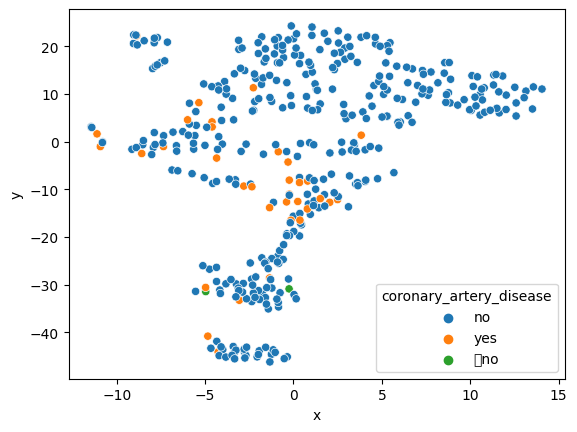

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
# Create a boolean mask for categorical columns
categorical_mask = (kideny.dtypes == object)

# Get list of categorical column names
categorical_columns = kideny.columns[categorical_mask].tolist()

# Drop non-numeric data
kideny_numeric = kideny.drop(categorical_columns, axis=1)

# Create a t-SNE model with learning rate 50
m = TSNE(learning_rate=50)

# Fit and transform the t-SNE model on the numeric dataset
tsne_features = m.fit_transform(kideny_numeric)

kideny["x"]=tsne_features[:,0]
kideny["y"]=tsne_features[:,1]

sns.scatterplot(x="x",y="y",hue = "coronary_artery_disease",data=kideny)
plt.show()

In [ ]:
kideny["class"].value_counts()

1    248
0    150
2      2
Name: class, dtype: int64

In [ ]:
kideny= kideny.drop(["x","y"], axis=1)
kideny.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,0,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,0,normal,notpresent,notpresent,0.0,...,38,6000,0,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,0,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,1


<ipython-input-17-04578e47ede9>:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  mask = np.triu(np.ones_like(kideny.corr(), dtype=bool))
<ipython-input-17-04578e47ede9>:6: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corplot = sns.heatmap(kideny.corr(),cmap=cmap, center=0,annot=True,fmt=".2f",linewidths=1, mask=mask )


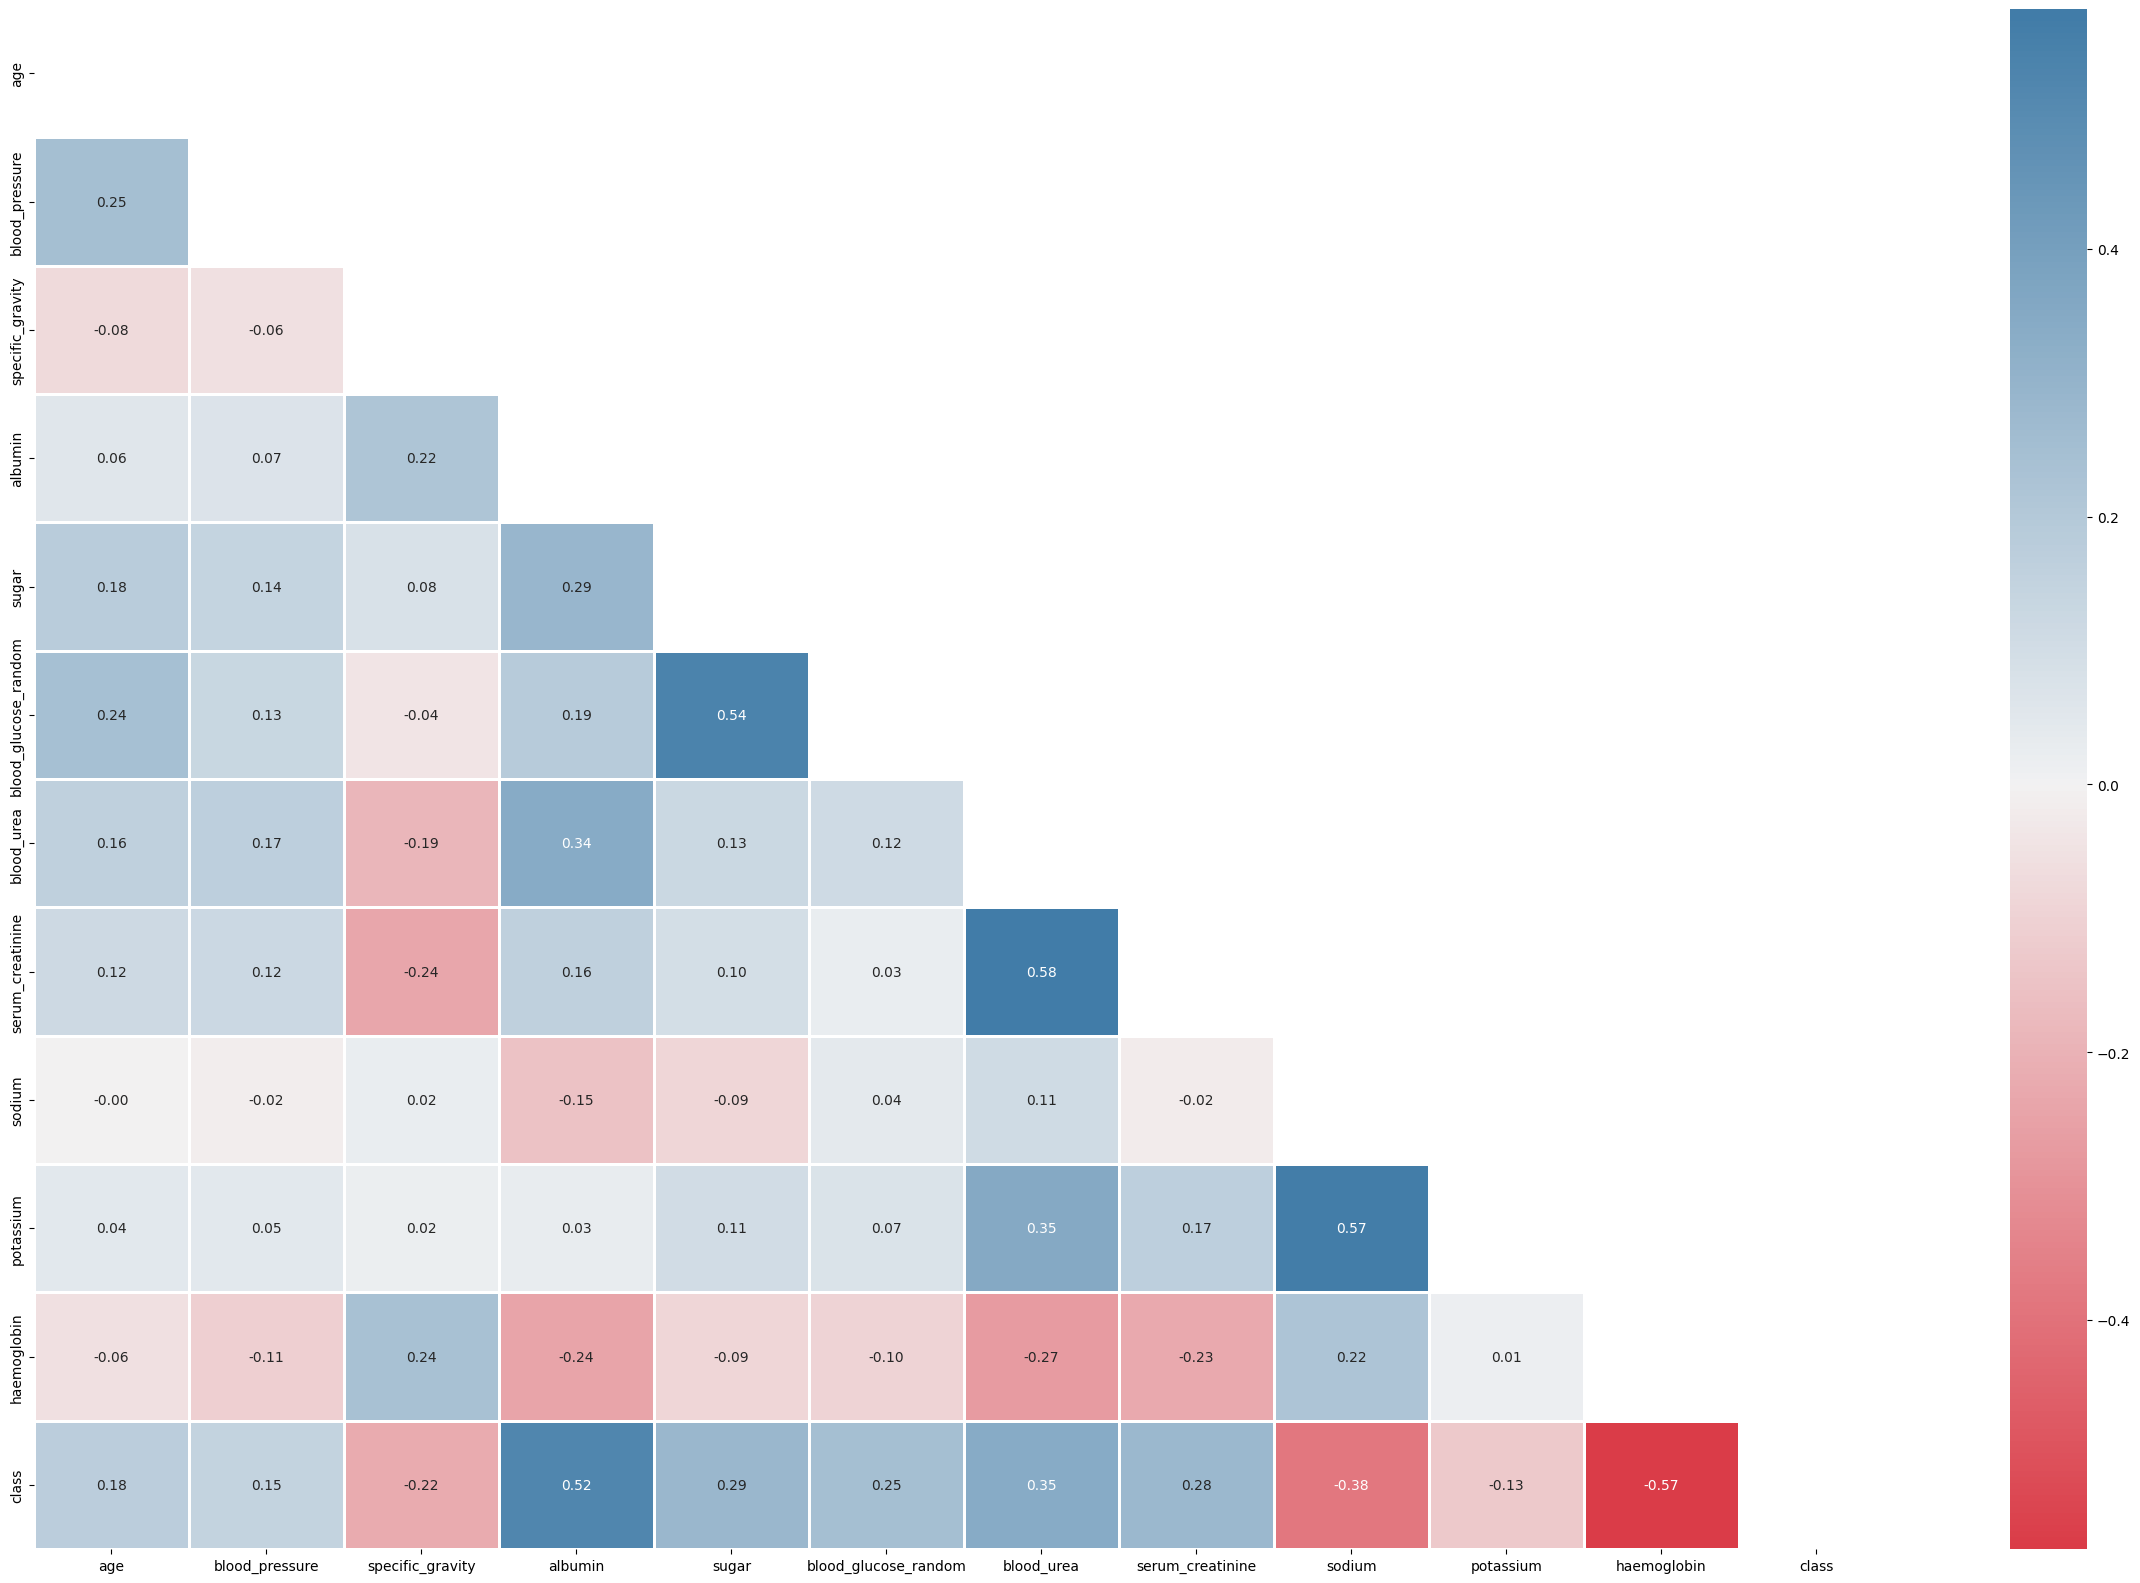

In [ ]:
fig, ax = plt.subplots(figsize=(30, 20))

# looking at the correlation of numerical data
cmap = sns.diverging_palette(h_neg=10, h_pos=240, as_cmap=True)
mask = np.triu(np.ones_like(kideny.corr(), dtype=bool))
corplot = sns.heatmap(kideny.corr(),cmap=cmap, center=0,annot=True,fmt=".2f",linewidths=1, mask=mask )

plt.show()

In [ ]:
# Create a boolean mask for categorical columns
categorical_mask = (kideny.dtypes == object)

# Get list of categorical column names
categorical_columns = kideny.columns[categorical_mask].tolist()

kideny_numeric =kideny.drop(categorical_columns, axis=1)
print(kideny_numeric.head())

    age  blood_pressure  specific_gravity  albumin  sugar  \
0  48.0            80.0             1.020      1.0    0.0   
1   7.0            50.0             1.020      4.0    0.0   
2  62.0            80.0             1.010      2.0    3.0   
3  48.0            70.0             1.005      4.0    0.0   
4  51.0            80.0             1.010      2.0    0.0   

   blood_glucose_random  blood_urea  serum_creatinine  sodium  potassium  \
0                 121.0        36.0               1.2     0.0        0.0   
1                   0.0        18.0               0.8     0.0        0.0   
2                 423.0        53.0               1.8     0.0        0.0   
3                 117.0        56.0               3.8   111.0        2.5   
4                 106.0        26.0               1.4     0.0        0.0   

   haemoglobin  class  
0         15.4      1  
1         11.3      1  
2          9.6      1  
3         11.2      1  
4         11.6      1  


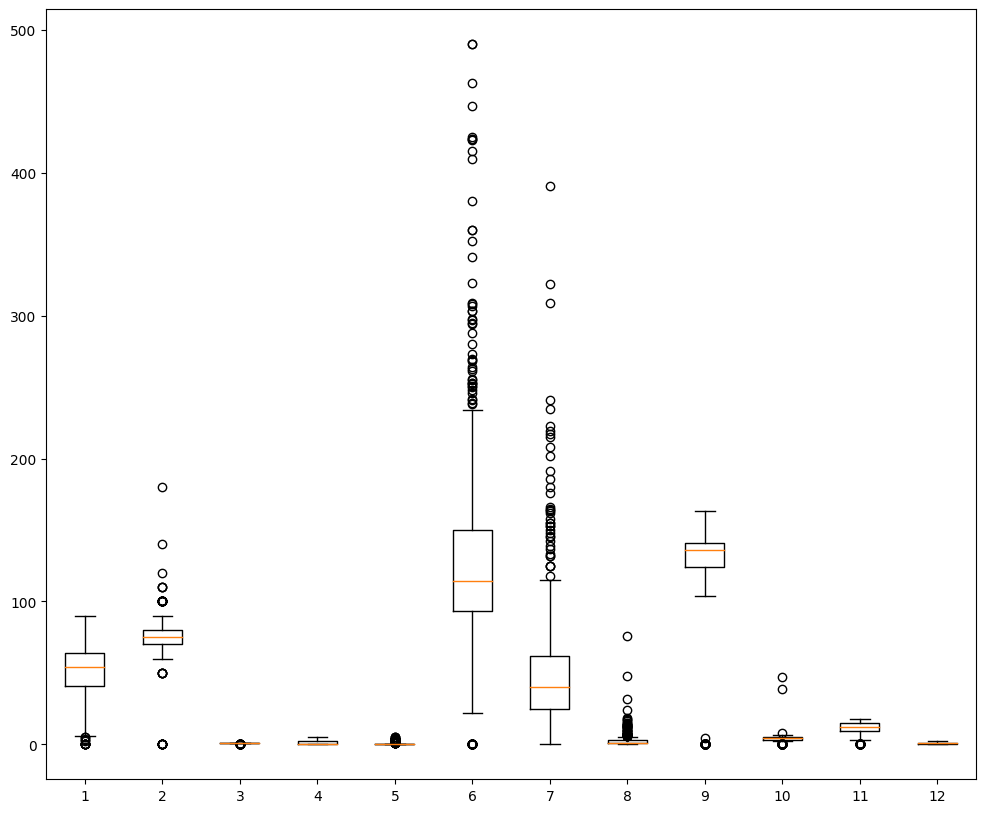

In [ ]:
fig = plt.figure(figsize =(12, 10))

# Creating plot
plt.boxplot(kideny_numeric)

# show plot
plt.show()

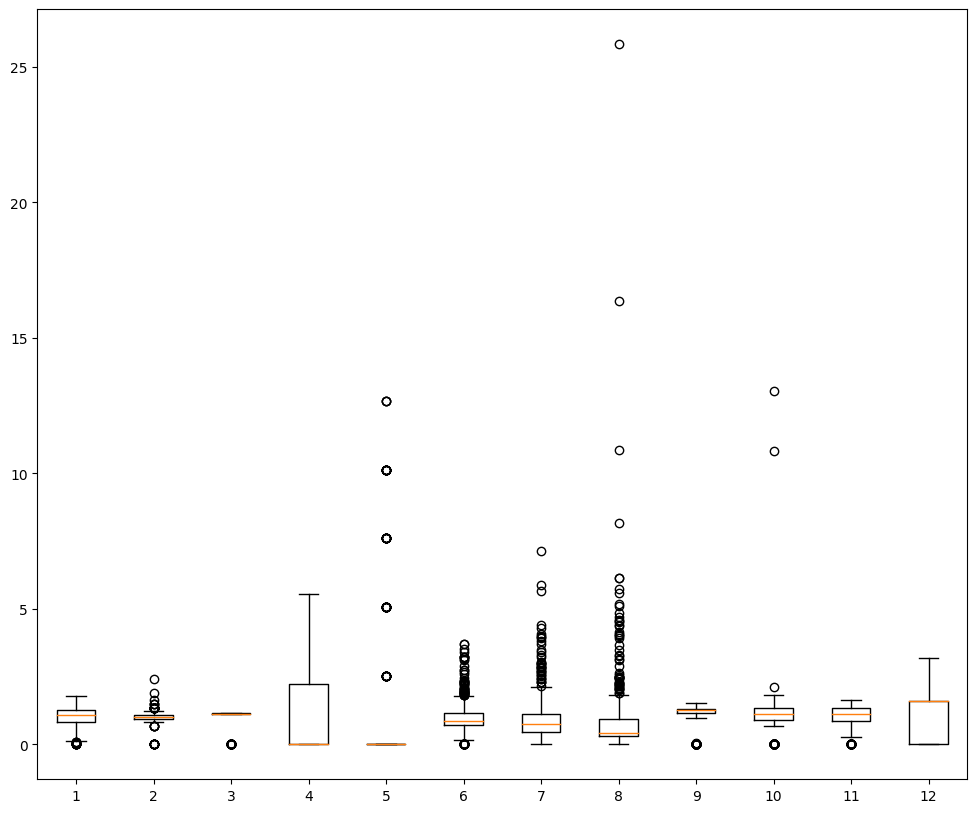

age                     0.136851
blood_pressure          0.064014
specific_gravity        0.133514
albumin                 2.128779
sugar                   6.932730
blood_glucose_random    0.446074
blood_urea              0.861893
serum_creatinine        3.690662
sodium                  0.285967
potassium               0.893134
haemoglobin             0.211918
class                   0.614032
dtype: float64


In [ ]:
# Normalize the data
normalized_kideny = kideny_numeric/kideny_numeric.mean()

fig = plt.figure(figsize =(12, 10))

# Creating plot
plt.boxplot(normalized_kideny)

# show plot
plt.show()

print(normalized_kideny.var())

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Create a VarianceThreshold feature selector
sel = VarianceThreshold(threshold=0.1)

# Fit the selector to normalized head_df
sel.fit(normalized_kideny)

# Create a boolean mask
mask = sel.get_support()

# Apply the mask to create a reduced DataFrame
reduced_kideny = kideny_numeric.loc[:, mask]

print(f"Dimensionality reduced from {kideny_numeric.shape[1]} to {reduced_kideny.shape[1]}.")

print(reduced_kideny.shape)
print(reduced_kideny.info())

Dimensionality reduced from 12 to 11.
(400, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   400 non-null    float64
 1   specific_gravity      400 non-null    float64
 2   albumin               400 non-null    float64
 3   sugar                 400 non-null    float64
 4   blood_glucose_random  400 non-null    float64
 5   blood_urea            400 non-null    float64
 6   serum_creatinine      400 non-null    float64
 7   sodium                400 non-null    float64
 8   potassium             400 non-null    float64
 9   haemoglobin           400 non-null    float64
 10  class                 400 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 34.5 KB
None


In [ ]:
kideny = pd.get_dummies(kideny)

In [ ]:
kideny.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Columns: 233 entries, age to aanemia_yes
dtypes: float64(11), int64(1), uint8(221)
memory usage: 124.0 KB


In [ ]:
X = kideny.drop(["class","blood_pressure"],axis=1)
y = kideny["class"]

In [ ]:
#Import train_test_split and stratify the data using y
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


# Use stratified sampling to split up the dataset according to the y dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state=42)

scaler =StandardScaler()
knn = KNeighborsClassifier()

X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn.fit(X_train_scaled,y_train)
ypred =knn.predict(X_test_scaled)

knn.score(X_test_scaled,y_test)

0.98

In [ ]:
accuracy_list=[]
for i in range(2,20):
  scaler =StandardScaler()
  knn = KNeighborsClassifier(n_neighbors=i)

  X_train_scaled =scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  knn.fit(X_train_scaled,y_train)
  ypred =knn.predict(X_test_scaled)

  accuracy_list.append(knn.score(X_test_scaled,y_test))

In [ ]:
accuracy_list=[]
for i in range(1,21):
  scaler =StandardScaler()
  knn = KNeighborsClassifier(n_neighbors=i)

  X_train_scaled =scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  knn.fit(X_train_scaled,y_train)
  ypred =knn.predict(X_test_scaled)

  accuracy_list.append(knn.score(X_test_scaled,y_test))

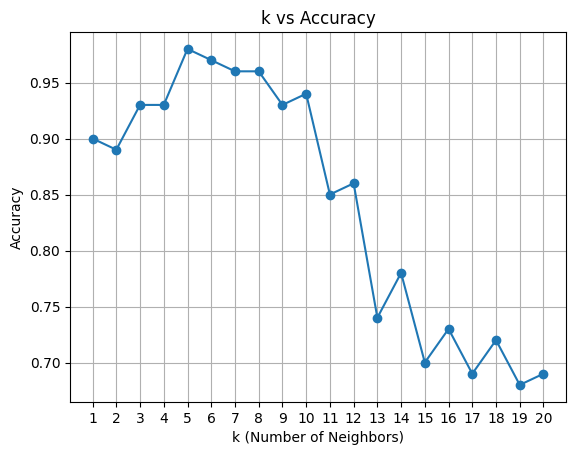

In [ ]:
accuracy_list = []

for i in range(1, 21):
    scaler = StandardScaler()
    knn = KNeighborsClassifier(n_neighbors=i)

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    knn.fit(X_train_scaled, y_train)
    accuracy = knn.score(X_test_scaled, y_test)

    accuracy_list.append(accuracy)

# Plotting the graph
plt.plot(range(1, 21), accuracy_list, marker='o')
plt.title('k vs Accuracy')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))  # Optional: Set x-axis ticks to the values of k
plt.grid(True)
plt.show()

In [ ]:
accuracy_list

[0.825,
 0.8875,
 0.9125,
 0.9375,
 0.95,
 0.925,
 0.95,
 0.95,
 0.9625,
 0.9625,
 0.9625,
 0.9625,
 0.9625,
 0.9625,
 0.9625,
 0.9625,
 0.925,
 0.9375,
 0.875,
 0.8625]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Assuming you have X_train, X_test, y_train, and y_test defined

best_accuracy = 0
best_k = 0
accuracy_list = []

for i in range(1, 21):
    scaler = StandardScaler()
    knn = KNeighborsClassifier(n_neighbors=i)

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    knn.fit(X_train_scaled, y_train)
    accuracy = knn.score(X_test_scaled, y_test)

    accuracy_list.append(accuracy)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = i

print(f"The best accuracy is {best_accuracy:.4f} with k = {best_k}")


The best accuracy is 0.9625 with k = 9
